In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

In [3]:
base=['engine_displacement','horsepower','vehicle_weight','model_year']
df[base].head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,2180,243.0,3870,2006
1,2390,272.0,4210,2008
2,2320,267.0,4240,1996
3,2130,258.0,4490,1989
4,2580,304.0,4510,1994


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

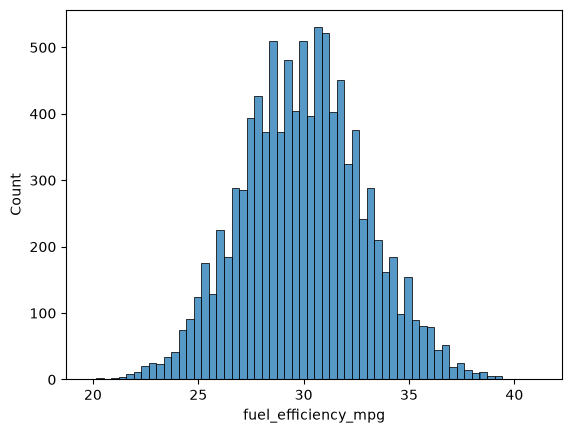

In [5]:
sns.histplot(df['fuel_efficiency_mpg'])

In [6]:
#Q1 There's one column with missing values. What is it?

In [7]:
df[base].isnull().sum() > 0

engine_displacement    False
horsepower              True
vehicle_weight         False
model_year             False
dtype: bool

In [8]:
# Q2
df['horsepower'].median()

np.float64(254.0)

In [9]:
import numpy as np

In [10]:
#Q3 Linear regression for car fuel efficiency


In [11]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def use_linear_regression(df, y):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(42)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    y_train = y.iloc[idx[:n_train]]
    y_val = y.iloc[idx[n_train:n_train + n_val]]
    y_test = y.iloc[idx[n_train + n_val:]]
    
    w0, w = train_linear_regression(df_train, y_train)
    y_pred = w0 + df_val.dot(w)
    
    RMSE = np.sqrt(np.mean((y_pred - y_val) ** 2))
    return round(RMSE, 3)

In [12]:
# Fill with mean
y=df['fuel_efficiency_mpg'].copy()
df_mean=df[base].copy()
df_null=df[base].copy()
mean=df['horsepower'].mean()
df_mean['horsepower'] = df_mean['horsepower'].fillna(mean)
df_null['horsepower'] = df_null['horsepower'].fillna(0)

# df_null
solution = [use_linear_regression(df_mean, y).mean(), use_linear_regression(df_null, y).mean()]
solution

[np.float64(2.202), np.float64(2.205)]

In [13]:
# Q4 using df_null: CHANGE REGULARIZATION

In [14]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def use_linear_regression_reg(df, y, r):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(42)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    y_train = y.iloc[idx[:n_train]]
    y_val = y.iloc[idx[n_train:n_train + n_val]]
    y_test = y.iloc[idx[n_train + n_val:]]
    
    w0, w = train_linear_regression_reg(df_train, y_train,r)
    y_pred = w0 + df_val.dot(w)
    
    RMSE = np.sqrt(np.mean((y_pred - y_val) ** 2))
    return round(RMSE, 4)


In [38]:
df_null=df[base].copy()
df_null['horsepower'] = df_null['horsepower'].fillna(0)
r = np.array([0, 0.01, 0.1, 1, 5, 10, 100])
# df_null
solution = []
for i in range(len(r)):
    solution.append(
        use_linear_regression_reg(df_null, y,r[i])
    )

solution_df = pd.DataFrame({
    'r': r,
    'solution': solution
})

#print(solution_df.sort_values)
print(solution_df)

        r  solution
0    0.00    2.2217
1    0.01    2.2220
2    0.10    2.2387
3    1.00    2.3629
4    5.00    2.4235
5   10.00    2.4337
6  100.00    2.4435


In [16]:
# Q5 CHANGE SEED
import numpy as np

In [17]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def use_linear_regression(df, y, s):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    y_train = y.iloc[idx[:n_train]]
    y_val = y.iloc[idx[n_train:n_train + n_val]]
    y_test = y.iloc[idx[n_train + n_val:]]
    
    w0, w = train_linear_regression(df_train, y_train)
    y_pred = w0 + df_val.dot(w)
    
    RMSE = np.sqrt(np.mean((y_pred - y_val) ** 2))
    return RMSE

In [35]:
s = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
df_null=df[base].copy()
df_null['horsepower'] = df_null['horsepower'].fillna(0)
y=df['fuel_efficiency_mpg'].copy()

solution = []
for i in range(len(s)):
    solution.append(
        use_linear_regression(df_null, y,s[i])
    )
#solution_df = pd.DataFrame(solution)
#print(solution_df.sort_values)
print(solution)
print(round(np.std(solution),3))


[np.float64(2.2392041430461465), np.float64(2.2021128210838907), np.float64(2.163419778753095), np.float64(2.2043588768539144), np.float64(2.2018800943312926), np.float64(2.2457851509084974), np.float64(2.269721207952404), np.float64(2.190794599933433), np.float64(2.2166112016864443), np.float64(2.207036592817851)]
0.029


In [19]:
s = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
df_null=df[base].copy()
df_null['horsepower'] = df_null['horsepower'].fillna(0)
y=df['fuel_efficiency_mpg'].copy()

solution = []
for i in range(len(s)):
    solution.append(
        use_linear_regression(df_null, y,s[i]).mean()
    )
#solution_df = pd.DataFrame(solution)
#print(solution_df.sort_values)
print(solution)
print(round(np.std(solution),3))

[np.float64(2.2392041430461465), np.float64(2.2021128210838907), np.float64(2.163419778753095), np.float64(2.2043588768539144), np.float64(2.2018800943312926), np.float64(2.2457851509084974), np.float64(2.269721207952404), np.float64(2.190794599933433), np.float64(2.2166112016864443), np.float64(2.207036592817851)]
0.029


In [24]:
# Q6

In [32]:
def train_linear_regression_reg_new(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def use_linear_regression_reg_new(df, y, r):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(9)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    df_train_and_validation = pd.concat([df_train, df_val])
    
    y_train = y.iloc[idx[:n_train]]
    y_val = y.iloc[idx[n_train:n_train + n_val]]
    y_test = y.iloc[idx[n_train + n_val:]]
    y_train_full = pd.concat([y_train, y_val])
    
    
    w0, w = train_linear_regression_reg_new(df_train_and_validation, y_train_full,r)
    y_pred = w0 + df_test.dot(w)
    
    RMSE = np.sqrt(np.mean((y_pred - y_test) ** 2))
    return round(RMSE, 3)

In [34]:
df_null=df[base].copy()
df_null['horsepower'] = df_null['horsepower'].fillna(0)
use_linear_regression_reg_new(df_null, y, 0.001)

np.float64(2.236)